# ℓ-Loop Diagram Enumeration using SageMath

This notebook generates all topologies for ℓ-loop corrections to the k-point function.

## Theory

For a topology G = T + F where:
- T is a tree with k+j leaves
- F is a multiset of ℓ edges (counting multiplicities)

Constraints:
1. 0 ≤ j ≤ ℓ + ⌊ℓ/2⌋
2. |V₃ᵀ| ≤ k+j-2 (vertices of degree ≥3 in T)
3. |V₂ᵀ| ≤ 2|V₃ᵀ| + 3ℓ - k - 3j - ⌊j/3⌋ + 3
4. G has no adjacent degree-2 vertices
5. Any degree ≥3 vertex in G has at least one non-degree-2 neighbor
6. Vertices adjacent to leaves of G are not all degree 2

In [1]:
# Cell 1: Imports and Setup
from sage.all import *
from itertools import combinations, combinations_with_replacement
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np

print("SageMath version:", version())
print("nauty available:", graphs.nauty_geng is not None)

SageMath version: SageMath version 10.8, Release Date: 2025-12-18
nauty available: True


In [2]:
# Cell 2: Core Graph Theory Functions

def classify_vertices_sage(G):
    """
    Classify vertices by degree.
    Returns (leaves, internal, degree_2, degree_3plus)
    """
    leaves = [v for v in G.vertices() if G.degree(v) == 1]
    internal = [v for v in G.vertices() if G.degree(v) > 1]
    degree_2 = [v for v in G.vertices() if G.degree(v) == 2]
    degree_3plus = [v for v in G.vertices() if G.degree(v) >= 3]
    
    return leaves, internal, degree_2, degree_3plus

def has_adjacent_degree2_sage(G, degree_2_vertices):
    """Check if any two degree-2 vertices are adjacent."""
    degree_2_set = set(degree_2_vertices)
    
    for v in degree_2_vertices:
        for neighbor in G.neighbors(v):
            if neighbor in degree_2_set and neighbor != v:
                return True
    return False

def check_deg3_has_non_deg2_neighbor(G, deg3plus_vertices, deg2_vertices):
    """
    Check that every vertex of degree >=3 has at least one neighbor that is NOT degree 2.
    """
    deg2_set = set(deg2_vertices)
    
    for v in deg3plus_vertices:
        neighbors = G.neighbors(v)
        # Check if all neighbors are degree 2
        if all(n in deg2_set for n in neighbors):
            return False
    return True

def check_leaf_neighbors_not_all_deg2(G, leaves, deg2_vertices):
    """
    Check that vertices adjacent to leaves are not ALL degree 2.
    """
    deg2_set = set(deg2_vertices)
    leaf_neighbors = set()
    
    for leaf in leaves:
        leaf_neighbors.update(G.neighbors(leaf))
    
    # If all leaf neighbors are degree 2, constraint is violated
    if leaf_neighbors and all(n in deg2_set for n in leaf_neighbors):
        return False
    return True

def count_cycles_sage(G):
    """
    Count independent cycles using cycle rank formula.
    For connected graph: cycles = edges - vertices + 1
    """
    n_edges = G.size()
    n_vertices = G.order()
    
    if not G.is_connected():
        return -1
    
    return n_edges - n_vertices + 1

def relabel_leaves_first(G):
    """
    Relabel graph so leaves are 0, 1, ..., k-1 and internal are k, k+1, ...
    """
    leaves, internal, _, _ = classify_vertices_sage(G)
    
    relabel_dict = {}
    for idx, v in enumerate(sorted(leaves)):
        relabel_dict[v] = idx
    for idx, v in enumerate(sorted(internal)):
        relabel_dict[v] = len(leaves) + idx
    
    G_relabeled = G.relabel(relabel_dict, inplace=False)
    
    return G_relabeled, relabel_dict

def graphs_isomorphic_with_labels(G1, leaves1, G2, leaves2):
    """
    Check if two multigraphs are isomorphic preserving leaf/internal labels.
    """
    if G1.order() != G2.order() or G1.size() != G2.size():
        return False
    
    if len(leaves1) != len(leaves2):
        return False
    
    leaves1_set = set(leaves1)
    leaves2_set = set(leaves2)
    
    G1_copy = G1.copy()
    G2_copy = G2.copy()
    
    for v in G1.vertices():
        G1_copy.set_vertex(v, 0 if v in leaves1_set else 1)
    for v in G2.vertices():
        G2_copy.set_vertex(v, 0 if v in leaves2_set else 1)
    
    return G1_copy.is_isomorphic(G2_copy)

In [3]:
def generate_trees_with_constraints(k, ell, max_vertices_search=50):
    """
    Generate all trees T with k+j leaves satisfying:
    - 0 ≤ j ≤ ell + floor(ell/2)
    - |V_3^T| ≤ k+j-2
    - |V_2^T| ≤ 2|V_3^T| + 3*ell - k - 3*j - floor(j/3) + 3
    
    OPTIMIZED: Only search vertex counts that could possibly satisfy constraints
    """
    valid_trees = []
    
    j_max = ell + (ell // 2)
    
    # For each j, calculate the range of possible vertex counts
    for j in range(0, j_max + 1):
        num_leaves = k + j
        
        # Calculate bounds for this specific j
        v3_max = k + j - 2
        v2_max = 2*v3_max + 3*ell - k - 3*j - (j // 3) + 3
        
        # Minimum vertices: just the leaves (but need ≥1 internal vertex if >1 leaf)
        min_n = num_leaves if num_leaves == 1 else num_leaves + 1
        
        # Maximum vertices: leaves + max internal vertices
        # But be reasonable - usually we don't need huge trees
        max_n = min(num_leaves + v2_max + v3_max, max_vertices_search)
        
        # Further optimization: most useful trees are smaller
        # Cap the search even more aggressively
        reasonable_max = num_leaves + min(10, v2_max + v3_max)
        max_n = min(max_n, reasonable_max)
        
        if max_n < min_n:
            continue
        
        for n in range(min_n, max_n + 1):
            for tree in graphs.trees(n):
                leaves, internal, degree_2, degree_3plus = classify_vertices_sage(tree)
                
                # Quick check: right number of leaves?
                if len(leaves) != num_leaves:
                    continue
                
                # Check V_3 constraint
                if len(degree_3plus) > v3_max:
                    continue
                
                # Check V_2 constraint  
                if len(degree_2) > v2_max:
                    continue
                
                valid_trees.append((tree, j, num_leaves))
    
    return valid_trees

print("Tree generation functions defined.")


Tree generation functions defined.


In [4]:
# Cell 4: Edge Addition for ℓ-loop Multigraphs

def generate_edge_multisets(all_vertices, ell):
    """
    Generate all multisets of ell edges from ALL vertices (not just internal).
    Each edge is a pair of DISTINCT vertices (no self-loops).
    
    Returns list of edge multisets, where each multiset is a list of (v1, v2) tuples.
    """
    if len(all_vertices) < 2:
        return []
    
    # Generate all possible edges between ANY vertices
    possible_edges = list(combinations(all_vertices, 2))
    
    # Generate all multisets of size ell from possible_edges
    # Use combinations_with_replacement to allow repeated edges (multigraph)
    edge_multisets = list(combinations_with_replacement(possible_edges, ell))
    
    return edge_multisets

def add_edges_to_tree(tree, edge_multiset):
    """
    Add edges from edge_multiset to tree to create multigraph.
    """
    G = Graph(tree, multiedges=True, loops=False)
    
    for edge in edge_multiset:
        G.add_edge(edge[0], edge[1])
    
    return G

def check_topology_constraints(G, k):
    """
    Check all topology constraints:
    1. No adjacent degree-2 vertices
    2. Any degree >=3 vertex has at least one non-degree-2 neighbor
    3. Vertices adjacent to leaves are not all degree 2
    4. Exactly k leaves
    5. Connected
    """
    leaves, internal, degree_2, degree_3plus = classify_vertices_sage(G)
    
    # Check leaf count
    if len(leaves) != k:
        return False
    
    # Check connected
    if not G.is_connected():
        return False
    
    # Check no adjacent degree-2 vertices
    if has_adjacent_degree2_sage(G, degree_2):
        return False
    
    # Check degree >=3 vertices have non-degree-2 neighbor
    if not check_deg3_has_non_deg2_neighbor(G, degree_3plus, degree_2):
        return False
    
    # Check leaf neighbors not all degree 2
    if not check_leaf_neighbors_not_all_deg2(G, leaves, degree_2):
        return False
    
    return True

print("Edge addition functions defined.")


Edge addition functions defined.


In [5]:
# Cell 5: Main Enumeration Function (with optional parallelization)

def enumerate_ell_loop_topologies(k, ell, n_threads=1, max_vertices_search=50, verbose=True):
    """
    Enumerate all unique topologies for ell-loop correction to k-point function.
    
    Args:
        k: k-point function
        ell: ell-loop correction  
        n_threads: Number of threads (1 = serial, >1 = parallel)
        max_vertices_search: Maximum vertices to search
        verbose: Print progress messages
    """
    if verbose:
        mode = "PARALLEL" if n_threads > 1 else "SERIAL"
        print(f"\n{'='*60}")
        print(f"ENUMERATING {ell}-LOOP TOPOLOGIES FOR k={k} ({mode})")
        if n_threads > 1:
            print(f"Using {n_threads} threads")
        print(f"{'='*60}\n")
    
    # Step 1: Generate trees with constraints
    if verbose:
        print("Step 1: Generating trees with constraints...")
    
    trees_with_j = generate_trees_with_constraints(k, ell, max_vertices_search)
    
    if verbose:
        print(f"  Found {len(trees_with_j)} valid trees")
        from collections import defaultdict
        j_counts = defaultdict(int)
        for _, j, _ in trees_with_j:
            j_counts[j] += 1
        for j in sorted(j_counts.keys()):
            print(f"    j={j}: {j_counts[j]} trees")
    
    # Step 2: Add edges and check constraints
    if verbose:
        print(f"\nStep 2: Adding {ell} edge(s) and checking topology constraints...")
    
    candidate_multigraphs = []
    
    if n_threads == 1:
        # Serial processing
        tree_count = 0
        total_trees = len(trees_with_j)
        
        for tree, j, num_leaves in trees_with_j:
            tree_count += 1
            if verbose and tree_count % 10 == 0:
                print(f"  Processing tree {tree_count}/{total_trees}...", end='\r')
            
            # Generate all multisets of ell edges from ALL vertices
            all_verts = list(tree.vertices())
            edge_multisets = generate_edge_multisets(all_verts, ell)
            
            for edge_multiset in edge_multisets:
                G = add_edges_to_tree(tree, edge_multiset)
                
                if count_cycles_sage(G) != ell:
                    continue
                
                if not check_topology_constraints(G, k):
                    continue
                
                G_relabeled, _ = relabel_leaves_first(G)
                leaves_final, internal_final, _, _ = classify_vertices_sage(G_relabeled)
                
                candidate_multigraphs.append((G_relabeled, leaves_final, internal_final))
        
        if verbose:
            print(f"  Processed {total_trees}/{total_trees} trees... Done!")
    else:
        # Parallel processing
        tree_args = [(tree, j, num_leaves, k, ell) for tree, j, num_leaves in trees_with_j]
        
        with ThreadPoolExecutor(max_workers=n_threads) as executor:
            futures = [executor.submit(process_tree_parallel, args) for args in tree_args]
            
            completed = 0
            for future in as_completed(futures):
                completed += 1
                if verbose and completed % 10 == 0:
                    print(f"  Processed {completed}/{len(trees_with_j)} trees...", end='\r')
                
                results = future.result()
                candidate_multigraphs.extend(results)
        
        if verbose:
            print(f"  Processed {len(trees_with_j)}/{len(trees_with_j)} trees... Done!")
    
    if verbose:
        print(f"  Generated {len(candidate_multigraphs)} candidate multigraphs")
    
    # Step 3: Remove isomorphic graphs (always serial for now - simpler)
    if verbose:
        print(f"\nStep 3: Removing isomorphic multigraphs...")
    
    unique_multigraphs = []
    
    for i, (G, leaves, internal) in enumerate(candidate_multigraphs):
        if verbose and i % 100 == 0:
            print(f"  Checked {i}/{len(candidate_multigraphs)}...", end='\r')
        
        is_new = True
        for G_unique, leaves_unique, _ in unique_multigraphs:
            if graphs_isomorphic_with_labels(G, leaves, G_unique, leaves_unique):
                is_new = False
                break
        
        if is_new:
            unique_multigraphs.append((G, leaves, internal))
    
    if verbose:
        print(f"  Checked {len(candidate_multigraphs)}/{len(candidate_multigraphs)}... Done!")
        print(f"\nFound {len(unique_multigraphs)} unique {ell}-loop topologies")
        print(f"\n{'='*60}")
        print(f"RESULT: {len(unique_multigraphs)} unique {ell}-loop topologies for k={k}")
        print(f"{'='*60}")
    
    return unique_multigraphs

print("Main enumeration function defined.")


Main enumeration function defined.


In [6]:
# Cell 5.5: Parallel Processing Helpers

def process_tree_parallel(args):
    """
    Process a single tree to generate candidate topologies.
    This function is defined at module level so it can be pickled.
    """
    tree, j, num_leaves, k, ell = args
    local_candidates = []
    
    # Generate all multisets of ell edges from ALL vertices
    all_verts = list(tree.vertices())
    edge_multisets = generate_edge_multisets(all_verts, ell)
    
    for edge_multiset in edge_multisets:
        G = add_edges_to_tree(tree, edge_multiset)
        
        # Check if it's ell-loop (cycle rank = ell)
        if count_cycles_sage(G) != ell:
            continue
        
        # Check topology constraints
        if not check_topology_constraints(G, k):
            continue
        
        # Relabel with leaves first
        G_relabeled, _ = relabel_leaves_first(G)
        leaves_final, internal_final, _, _ = classify_vertices_sage(G_relabeled)
        
        local_candidates.append((G_relabeled, leaves_final, internal_final))
    
    return local_candidates

def process_orientation_parallel(args):
    """
    Process a single topology to find all valid orientations.
    """
    G, leaves, internal = args
    orientations = enumerate_orientations(G, leaves)
    return [(D, G, leaves, internal) for D in orientations]

print("Parallel helper functions defined.")


Parallel helper functions defined.


## SageMath Parallelization Options

SageMath has a built-in `@parallel` decorator that works better with SageMath objects than standard Python threading:

```python
from sage.parallel.decorate import parallel

@parallel(ncpus=4)
def process_tree(tree, j, num_leaves, k, ell):
    # Your processing code
    return results

# Use it:
results = list(process_tree([(tree1, j1, ...), (tree2, j2, ...)]))
```

**Advantages:**
- Designed specifically for SageMath objects (graphs, etc.)
- Handles pickling of SageMath objects better
- Simpler syntax than ThreadPoolExecutor

**Current implementation uses ThreadPoolExecutor** because:
- More explicit control over execution
- Better progress tracking
- Works reliably in Jupyter notebooks

You can try `@parallel` if ThreadPoolExecutor has issues!

In [7]:
# Cell 5.7: Alternative - Using SageMath's @parallel decorator
#
# Uncomment this cell to use SageMath's built-in parallelization instead
#
# from sage.parallel.decorate import parallel
#
# @parallel(ncpus=4)  # Set number of CPUs here
# def process_tree_sage_parallel(tree, j, num_leaves, k, ell):
#     """Process tree using SageMath's @parallel decorator"""
#     local_candidates = []
#     
#     all_verts = list(tree.vertices())
#     edge_multisets = generate_edge_multisets(all_verts, ell)
#     
#     for edge_multiset in edge_multisets:
#         G = add_edges_to_tree(tree, edge_multiset)
#         
#         if count_cycles_sage(G) != ell:
#             continue
#         
#         if not check_topology_constraints(G, k):
#             continue
#         
#         G_relabeled, _ = relabel_leaves_first(G)
#         leaves_final, internal_final, _, _ = classify_vertices_sage(G_relabeled)
#         
#         local_candidates.append((G_relabeled, leaves_final, internal_final))
#     
#     return local_candidates
#
# # To use: Replace the parallel section in enumerate_ell_loop_topologies with:
# # tree_args = [(tree, j, num_leaves, k, ell) for tree, j, num_leaves in trees_with_j]
# # results = list(process_tree_sage_parallel(tree_args))
# # for inp, output in results:
# #     candidate_multigraphs.extend(output)

print("SageMath @parallel alternative defined (commented out).")
print("Uncomment and modify Cell 5 to use it if ThreadPoolExecutor has issues.")


SageMath @parallel alternative defined (commented out).
Uncomment and modify Cell 5 to use it if ThreadPoolExecutor has issues.


In [8]:
# Cell 6: Run Enumeration - Configure here

import time

k = 2  # k-point function
ell = 1  # ell-loop correction

# Parallelization settings
n_threads = 4  # Number of threads (set to 1 for serial, or higher for parallel)

# Start timing
start_time = time.time()

# Run enumeration
unique_multigraphs = enumerate_ell_loop_topologies(
    k, ell, n_threads=n_threads, max_vertices_search=20, verbose=True
)

# End timing
end_time = time.time()
elapsed = end_time - start_time

print(f"\n{'='*60}")
print(f"TIMING: Topology enumeration took {elapsed:.2f} seconds")
print(f"{'='*60}")



ENUMERATING 1-LOOP TOPOLOGIES FOR k=2 (PARALLEL)
Using 4 threads

Step 1: Generating trees with constraints...
  Found 11 valid trees
    j=0: 4 trees
    j=1: 7 trees

Step 2: Adding 1 edge(s) and checking topology constraints...
  Processed 11/11 trees... Done!
  Generated 22 candidate multigraphs

Step 3: Removing isomorphic multigraphs...
  Checked 22/22... Done!

Found 9 unique 1-loop topologies

RESULT: 9 unique 1-loop topologies for k=2

TIMING: Topology enumeration took 0.05 seconds



DISPLAYING ALL 11 TREES


Trees with j=0 (k+j=2 leaves): 4 trees


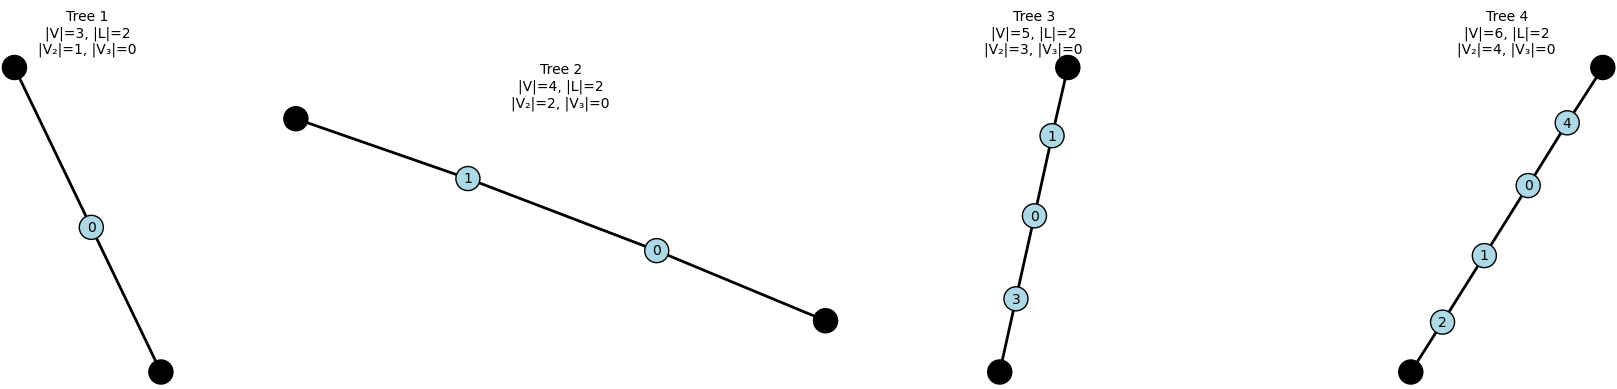


Tree Statistics for j=0:
  Tree 1: |V|=3, |E|=2, |L|=2, |V₂|=1, |V₃|=0
  Tree 2: |V|=4, |E|=3, |L|=2, |V₂|=2, |V₃|=0
  Tree 3: |V|=5, |E|=4, |L|=2, |V₂|=3, |V₃|=0
  Tree 4: |V|=6, |E|=5, |L|=2, |V₂|=4, |V₃|=0

Trees with j=1 (k+j=3 leaves): 7 trees


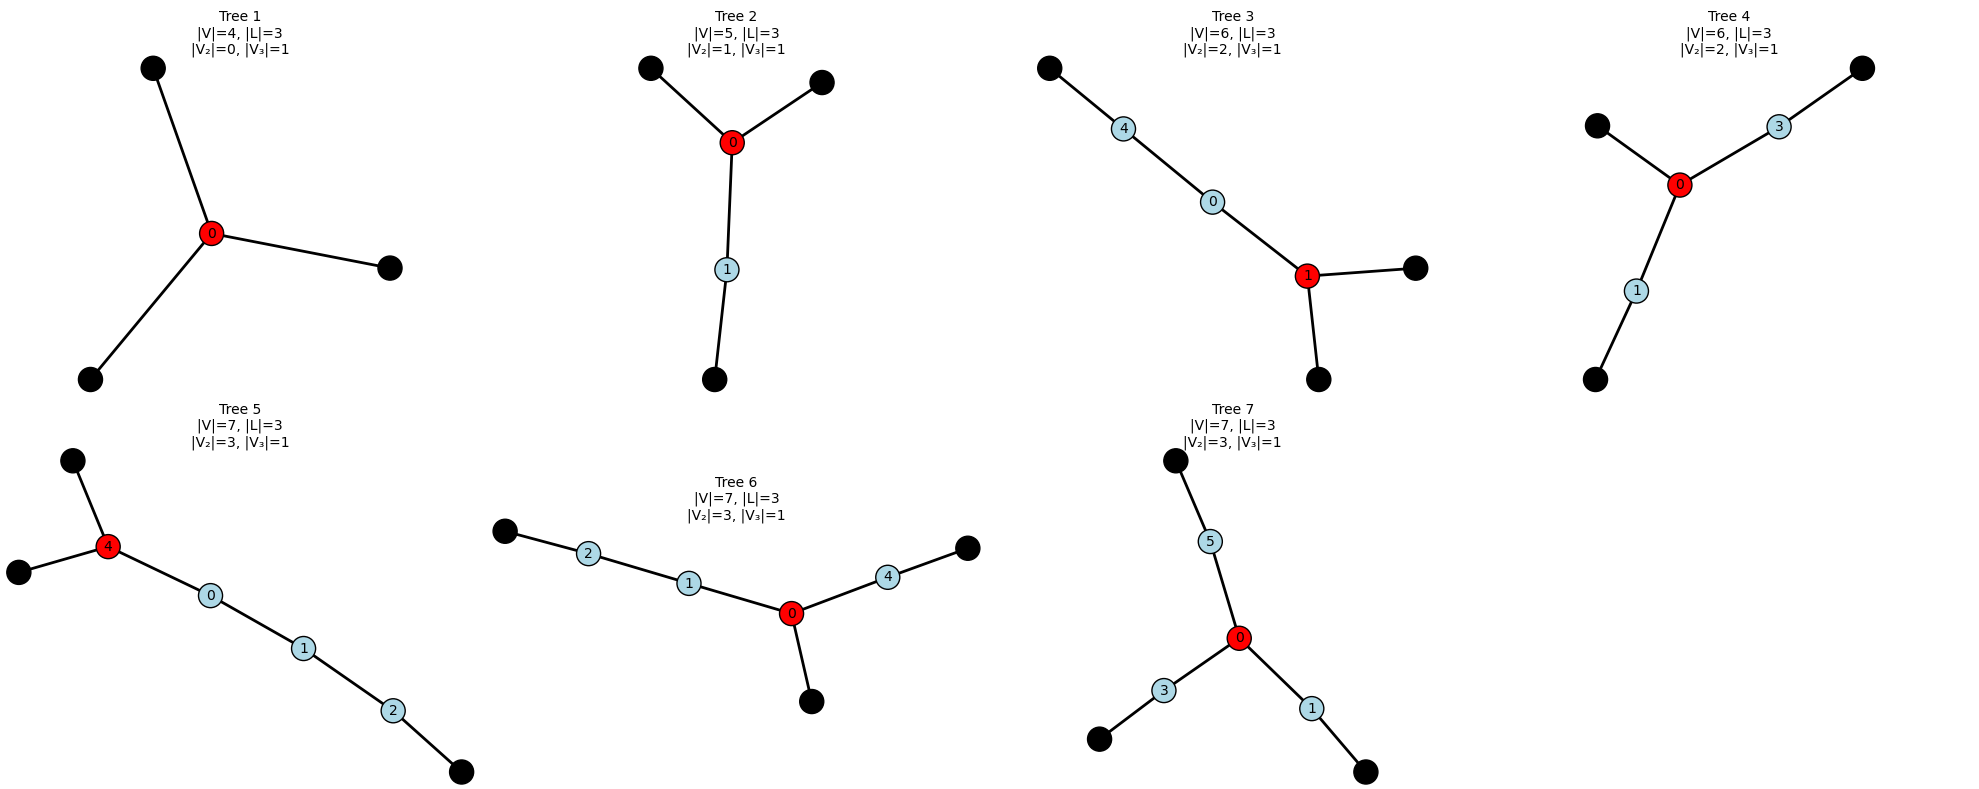


Tree Statistics for j=1:
  Tree 1: |V|=4, |E|=3, |L|=3, |V₂|=0, |V₃|=1
  Tree 2: |V|=5, |E|=4, |L|=3, |V₂|=1, |V₃|=1
  Tree 3: |V|=6, |E|=5, |L|=3, |V₂|=2, |V₃|=1
  Tree 4: |V|=6, |E|=5, |L|=3, |V₂|=2, |V₃|=1
  Tree 5: |V|=7, |E|=6, |L|=3, |V₂|=3, |V₃|=1
  Tree 6: |V|=7, |E|=6, |L|=3, |V₂|=3, |V₃|=1
  Tree 7: |V|=7, |E|=6, |L|=3, |V₂|=3, |V₃|=1

TOTAL: 11 trees across all j values


In [9]:
# Cell 6.5: Visualize All Generated Trees (Before Edge Addition)

# First, regenerate trees to display them
trees_with_j = generate_trees_with_constraints(k, ell, max_vertices_search=20)

print(f"\n{'='*60}")
print(f"DISPLAYING ALL {len(trees_with_j)} TREES")
print(f"{'='*60}\n")

# Group by j for better organization
from collections import defaultdict
trees_by_j = defaultdict(list)
for tree, j, num_leaves in trees_with_j:
    trees_by_j[j].append((tree, num_leaves))

# Display trees grouped by j
for j in sorted(trees_by_j.keys()):
    trees_for_this_j = trees_by_j[j]
    print(f"\n{'='*60}")
    print(f"Trees with j={j} (k+j={k+j} leaves): {len(trees_for_this_j)} trees")
    print(f"{'='*60}")
    
    if len(trees_for_this_j) > 0:
        # Visualize these trees
        n_trees = len(trees_for_this_j)
        n_cols = min(4, n_trees)
        n_rows = (n_trees + n_cols - 1) // n_cols
        
        plots = []
        
        for idx, (tree, num_leaves) in enumerate(trees_for_this_j):
            leaves, internal, degree_2, degree_3plus = classify_vertices_sage(tree)
            
            # Color: leaves = black, degree-2 = lightblue, degree-3+ = red
            leaves_set = set(leaves)
            deg2_set = set(degree_2)
            deg3_set = set(degree_3plus)
            
            color_map = {}
            for v in tree.vertices():
                if v in leaves_set:
                    color_map.setdefault('black', []).append(v)
                elif v in deg2_set:
                    color_map.setdefault('lightblue', []).append(v)
                elif v in deg3_set:
                    color_map.setdefault('red', []).append(v)
            
            title = f"Tree {idx+1}\n|V|={tree.order()}, |L|={len(leaves)}\n|V₂|={len(degree_2)}, |V₃|={len(degree_3plus)}"
            
            plot = tree.plot(vertex_colors=color_map,
                             vertex_size=300,
                             edge_thickness=2,
                             title=title,
                             title_pos=(0.5, -0.1))
            plots.append(plot)
        
        from sage.plot.plot import graphics_array as ga_func
        ga = ga_func(plots, n_rows, n_cols)
        ga.save(f'trees_j{j}_{ell}loop_{k}point.png', figsize=[5*n_cols, 4*n_rows], dpi=150)
        ga.show(figsize=[5*n_cols, 4*n_rows])
        
        # Print statistics
        print(f"\nTree Statistics for j={j}:")
        for idx, (tree, num_leaves) in enumerate(trees_for_this_j):
            leaves, internal, degree_2, degree_3plus = classify_vertices_sage(tree)
            print(f"  Tree {idx+1}: |V|={tree.order()}, |E|={tree.size()}, "
                  f"|L|={len(leaves)}, |V₂|={len(degree_2)}, |V₃|={len(degree_3plus)}")

print(f"\n{'='*60}")
print(f"TOTAL: {len(trees_with_j)} trees across all j values")
print(f"{'='*60}")


In [10]:
# Cell 6.7: Debug - Show edge addition statistics

print("\n" + "="*60)
print("EDGE ADDITION DEBUG INFO")
print("="*60)

# Pick first tree and show what edges are being considered
if len(trees_with_j) > 0:
    tree, j, num_leaves = trees_with_j[0]
    all_verts = list(tree.vertices())
    
    print(f"\nExample tree: j={j}, |V|={len(all_verts)} vertices")
    print(f"Vertices: {all_verts}")
    
    # Show all possible edges
    from itertools import combinations
    possible_edges = list(combinations(all_verts, 2))
    print(f"\nNumber of possible edges (including between leaves): {len(possible_edges)}")
    
    # For ell=1, show what edges would be added
    if ell == 1:
        print(f"\nFor ell=1, we would add each of these {len(possible_edges)} edges one at a time:")
        for i, edge in enumerate(possible_edges[:10]):  # Show first 10
            print(f"  {edge}")
        if len(possible_edges) > 10:
            print(f"  ... and {len(possible_edges)-10} more")
    
    # For ell=2, show how many multisets
    if ell == 2:
        from itertools import combinations_with_replacement
        multisets = list(combinations_with_replacement(possible_edges, ell))
        print(f"\nFor ell=2, number of edge multisets: {len(multisets)}")
        print("Examples (first 5):")
        for i, ms in enumerate(multisets[:5]):
            print(f"  {ms}")

print(f"\n{'='*60}")



EDGE ADDITION DEBUG INFO

Example tree: j=0, |V|=3 vertices
Vertices: [0, 1, 2]

Number of possible edges (including between leaves): 3

For ell=1, we would add each of these 3 edges one at a time:
  (0, 1)
  (0, 2)
  (1, 2)



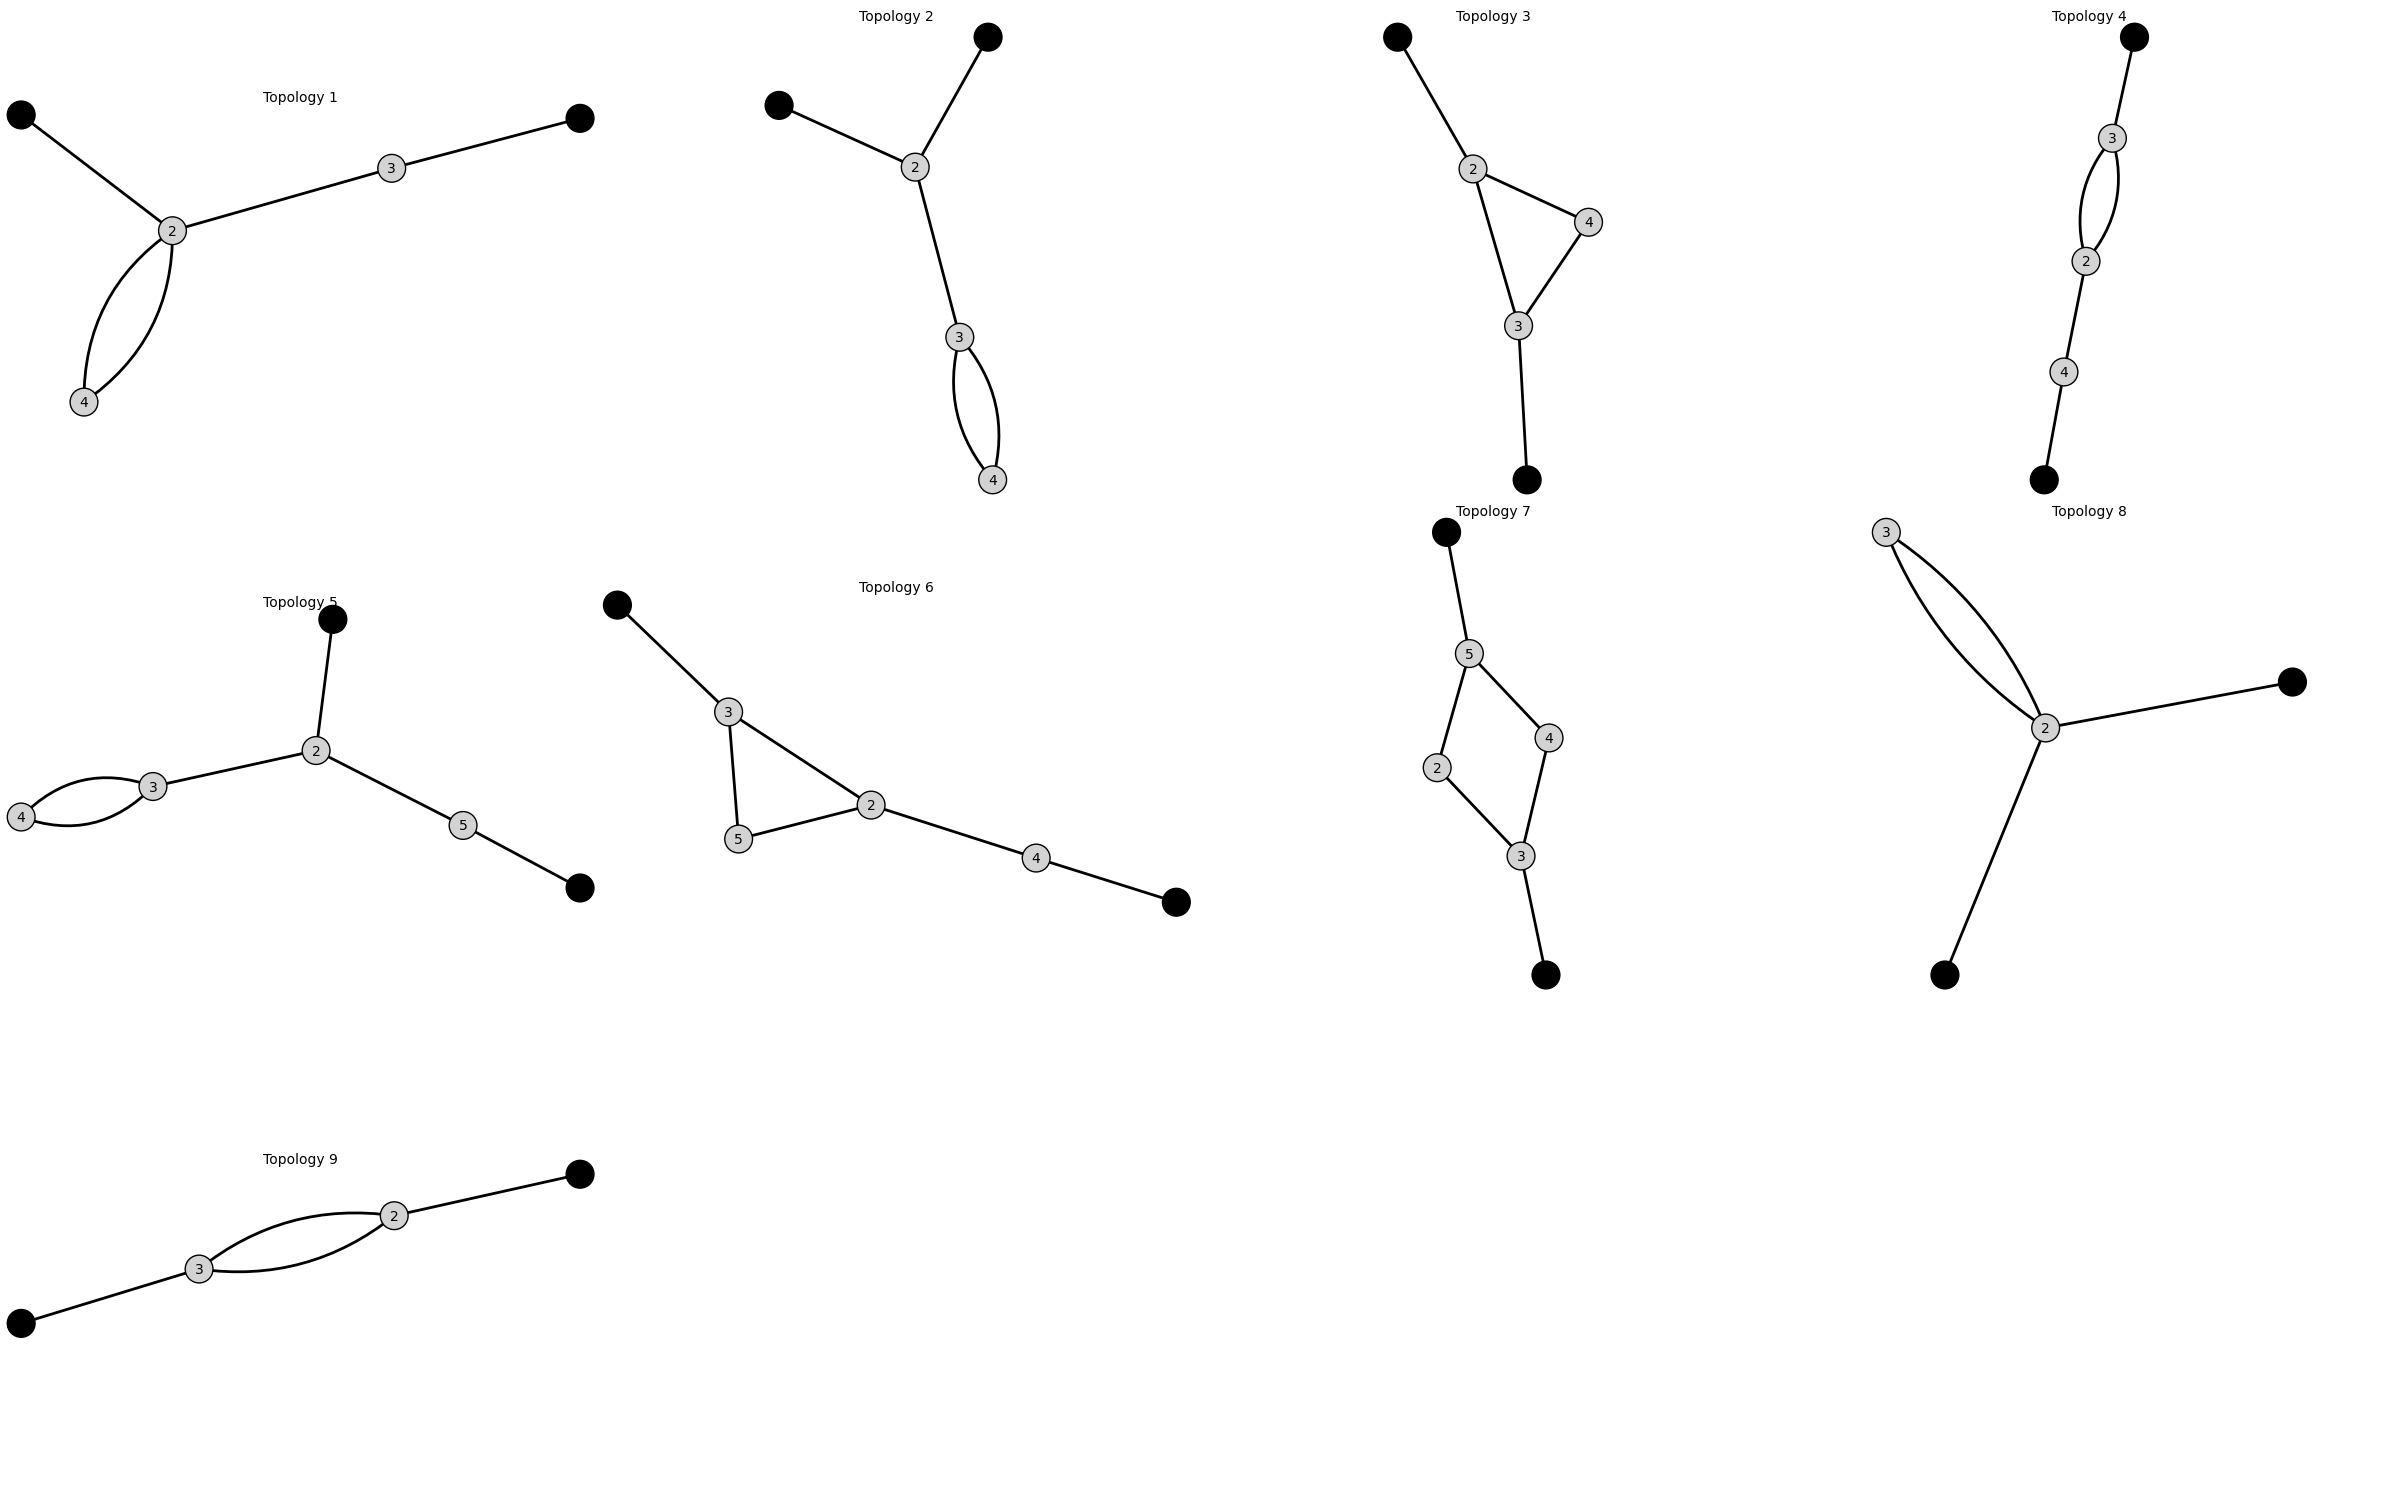

In [11]:
# Cell 7: Visualization of Undirected Topologies

n_graphs = len(unique_multigraphs)

if n_graphs == 0:
    print("No topologies to display!")
else:
    n_cols = min(4, n_graphs)
    n_rows = (n_graphs + n_cols - 1) // n_cols
    
    plots = []
    
    for i, (G, leaves, internal) in enumerate(unique_multigraphs):
        leaves_set = set(leaves)
        color_map = {}
        
        for v in G.vertices():
            if v in leaves_set:
                color_map.setdefault('black', []).append(v)
            else:
                color_map.setdefault('lightgray', []).append(v)
        
        plot = G.plot(vertex_colors=color_map,
                      vertex_size=400,
                      edge_thickness=2,
                      title=f"Topology {i+1}")
        plots.append(plot)
    
    from sage.plot.plot import graphics_array as ga_func
    ga = ga_func(plots, n_rows, n_cols)
    ga.save(f'topologies_{ell}_loop_{k}_point.png', figsize=[6*n_cols, 5*n_rows], dpi=150)
    ga.show(figsize=[6*n_cols, 5*n_rows])

In [12]:
# Cell 8: Orientation Enumeration (same as before)

def orient_edges(G, orientation_bits):
    """
    Create directed graph from undirected multigraph G using orientation_bits.
    orientation_bits: list of 0/1 for each edge (0 = u->v, 1 = v->u)
    """
    D = DiGraph(multiedges=True, loops=False)
    D.add_vertices(G.vertices())
    
    edges = list(G.edges(labels=False))
    
    for i, (u, v) in enumerate(edges):
        if orientation_bits[i] == 0:
            D.add_edge(u, v)
        else:
            D.add_edge(v, u)
    
    return D

def check_orientation_constraints(D, leaves):
    """
    Check orientation constraints from Proposition (pre-diagram rules):
    1. No directed cycles (DAG)
    2. No vertices with out_degree=0 and in_degree>=2
    3. No vertices with in_degree=1 and out_degree=1
    4. All degree-1 vertices have in_degree=1 (i.e., they are leaves/external)
    
    Additional constraint (not explicitly in proposition but implied):
    5. No adjacent sources (vertices with in_degree=0)
    """
    leaves_set = set(leaves)
    
    # Constraint 1: No directed cycles
    if not D.is_directed_acyclic():
        return False
    
    # Check constraints for all vertices
    for v in D.vertices():
        in_deg = D.in_degree(v)
        out_deg = D.out_degree(v)
        total_deg = in_deg + out_deg
        
        # Constraint 4: All degree-1 vertices have in_degree=1
        if total_deg == 1:
            if in_deg != 1:
                return False
        
        # Constraint 2: No vertices with out_degree=0 and in_degree>=2
        if out_deg == 0 and in_deg >= 2:
            return False
        
        # Constraint 3: No vertices with in_degree=1 and out_degree=1
        if in_deg == 1 and out_deg == 1:
            return False
    
    # Constraint 5: No adjacent sources
    sources = [v for v in D.vertices() if D.in_degree(v) == 0]
    for v in sources:
        for u in D.neighbors_out(v):
            if u in sources:
                return False
    
    return True

def enumerate_orientations(G, leaves):
    """
    Enumerate all valid orientations of multigraph G.
    """
    edges = list(G.edges(labels=False))
    n_edges = len(edges)
    
    valid_orientations = []
    
    # Try all 2^n_edges orientations
    for bits in range(2**n_edges):
        orientation = [(bits >> i) & 1 for i in range(n_edges)]
        
        D = orient_edges(G, orientation)
        
        if check_orientation_constraints(D, leaves):
            valid_orientations.append(D)
    
    return valid_orientations

def directed_graphs_isomorphic_with_labels(D1, leaves1, D2, leaves2):
    """
    Check if two directed multigraphs are isomorphic preserving leaf/internal labels.
    """
    if D1.order() != D2.order() or D1.size() != D2.size():
        return False
    
    if len(leaves1) != len(leaves2):
        return False
    
    leaves1_set = set(leaves1)
    leaves2_set = set(leaves2)
    
    D1_copy = D1.copy()
    D2_copy = D2.copy()
    
    for v in D1.vertices():
        D1_copy.set_vertex(v, 0 if v in leaves1_set else 1)
    for v in D2.vertices():
        D2_copy.set_vertex(v, 0 if v in leaves2_set else 1)
    
    return D1_copy.is_isomorphic(D2_copy)

def remove_isomorphic_directed(directed_diagrams):
    """
    Remove isomorphic directed diagrams.
    """
    unique = []
    
    for i, (D, G, leaves, internal) in enumerate(directed_diagrams):
        if i % 100 == 0:
            print(f"  Checking {i}/{len(directed_diagrams)}...", end='\r')
        
        is_new = True
        for D_unique, _, leaves_unique, _ in unique:
            if directed_graphs_isomorphic_with_labels(D, leaves, D_unique, leaves_unique):
                is_new = False
                break
        
        if is_new:
            unique.append((D, G, leaves, internal))
    
    print(f"  Checking {len(directed_diagrams)}/{len(directed_diagrams)}... Done!")
    return unique

print("Orientation functions defined.")

Orientation functions defined.


In [13]:
# Cell 9: Run Orientation Enumeration (with optional parallelization)

import time
orientation_start = time.time()

# Cell 9: Run Orientation Enumeration (with optional parallelization)

print(f"\nEnumerating orientations for {len(unique_multigraphs)} topologies...")

all_directed = []

if n_threads == 1:
    # Serial orientation enumeration
    for i, (G, leaves, internal) in enumerate(unique_multigraphs):
        if i % 10 == 0:
            print(f"  Processing topology {i+1}/{len(unique_multigraphs)}...", end='\r')
        
        orientations = enumerate_orientations(G, leaves)
        
        for D in orientations:
            all_directed.append((D, G, leaves, internal))
    
    print(f"  Processing topology {len(unique_multigraphs)}/{len(unique_multigraphs)}... Done!")
else:
    # Parallel orientation enumeration
    print(f"Using {n_threads} threads for orientation enumeration...")
    
    topology_args = [(G, leaves, internal) for G, leaves, internal in unique_multigraphs]
    
    with ThreadPoolExecutor(max_workers=n_threads) as executor:
        futures = [executor.submit(process_orientation_parallel, args) for args in topology_args]
        
        completed = 0
        for future in as_completed(futures):
            completed += 1
            if completed % 10 == 0:
                print(f"  Processed {completed}/{len(unique_multigraphs)} topologies...", end='\r')
            
            results = future.result()
            all_directed.extend(results)
    
    print(f"  Processed {len(unique_multigraphs)}/{len(unique_multigraphs)} topologies... Done!")

print(f"\nGenerated {len(all_directed)} oriented diagrams")

print("\nRemoving isomorphic directed diagrams...")
unique_directed_diagrams = remove_isomorphic_directed(all_directed)

print(f"\nFound {len(unique_directed_diagrams)} unique directed {ell}-loop diagrams for k={k}")

orientation_end = time.time()
orientation_elapsed = orientation_end - orientation_start

print(f"\n{'='*60}")
print(f"TIMING: Orientation enumeration took {orientation_elapsed:.2f} seconds")
print(f"Total time: {elapsed + orientation_elapsed:.2f} seconds")
print(f"{'='*60}")



Enumerating orientations for 9 topologies...
Using 4 threads for orientation enumeration...
  Processed 9/9 topologies... Done!

Generated 11 oriented diagrams

Removing isomorphic directed diagrams...
  Checking 11/11... Done!

Found 9 unique directed 1-loop diagrams for k=2

TIMING: Orientation enumeration took 0.01 seconds
Total time: 0.06 seconds


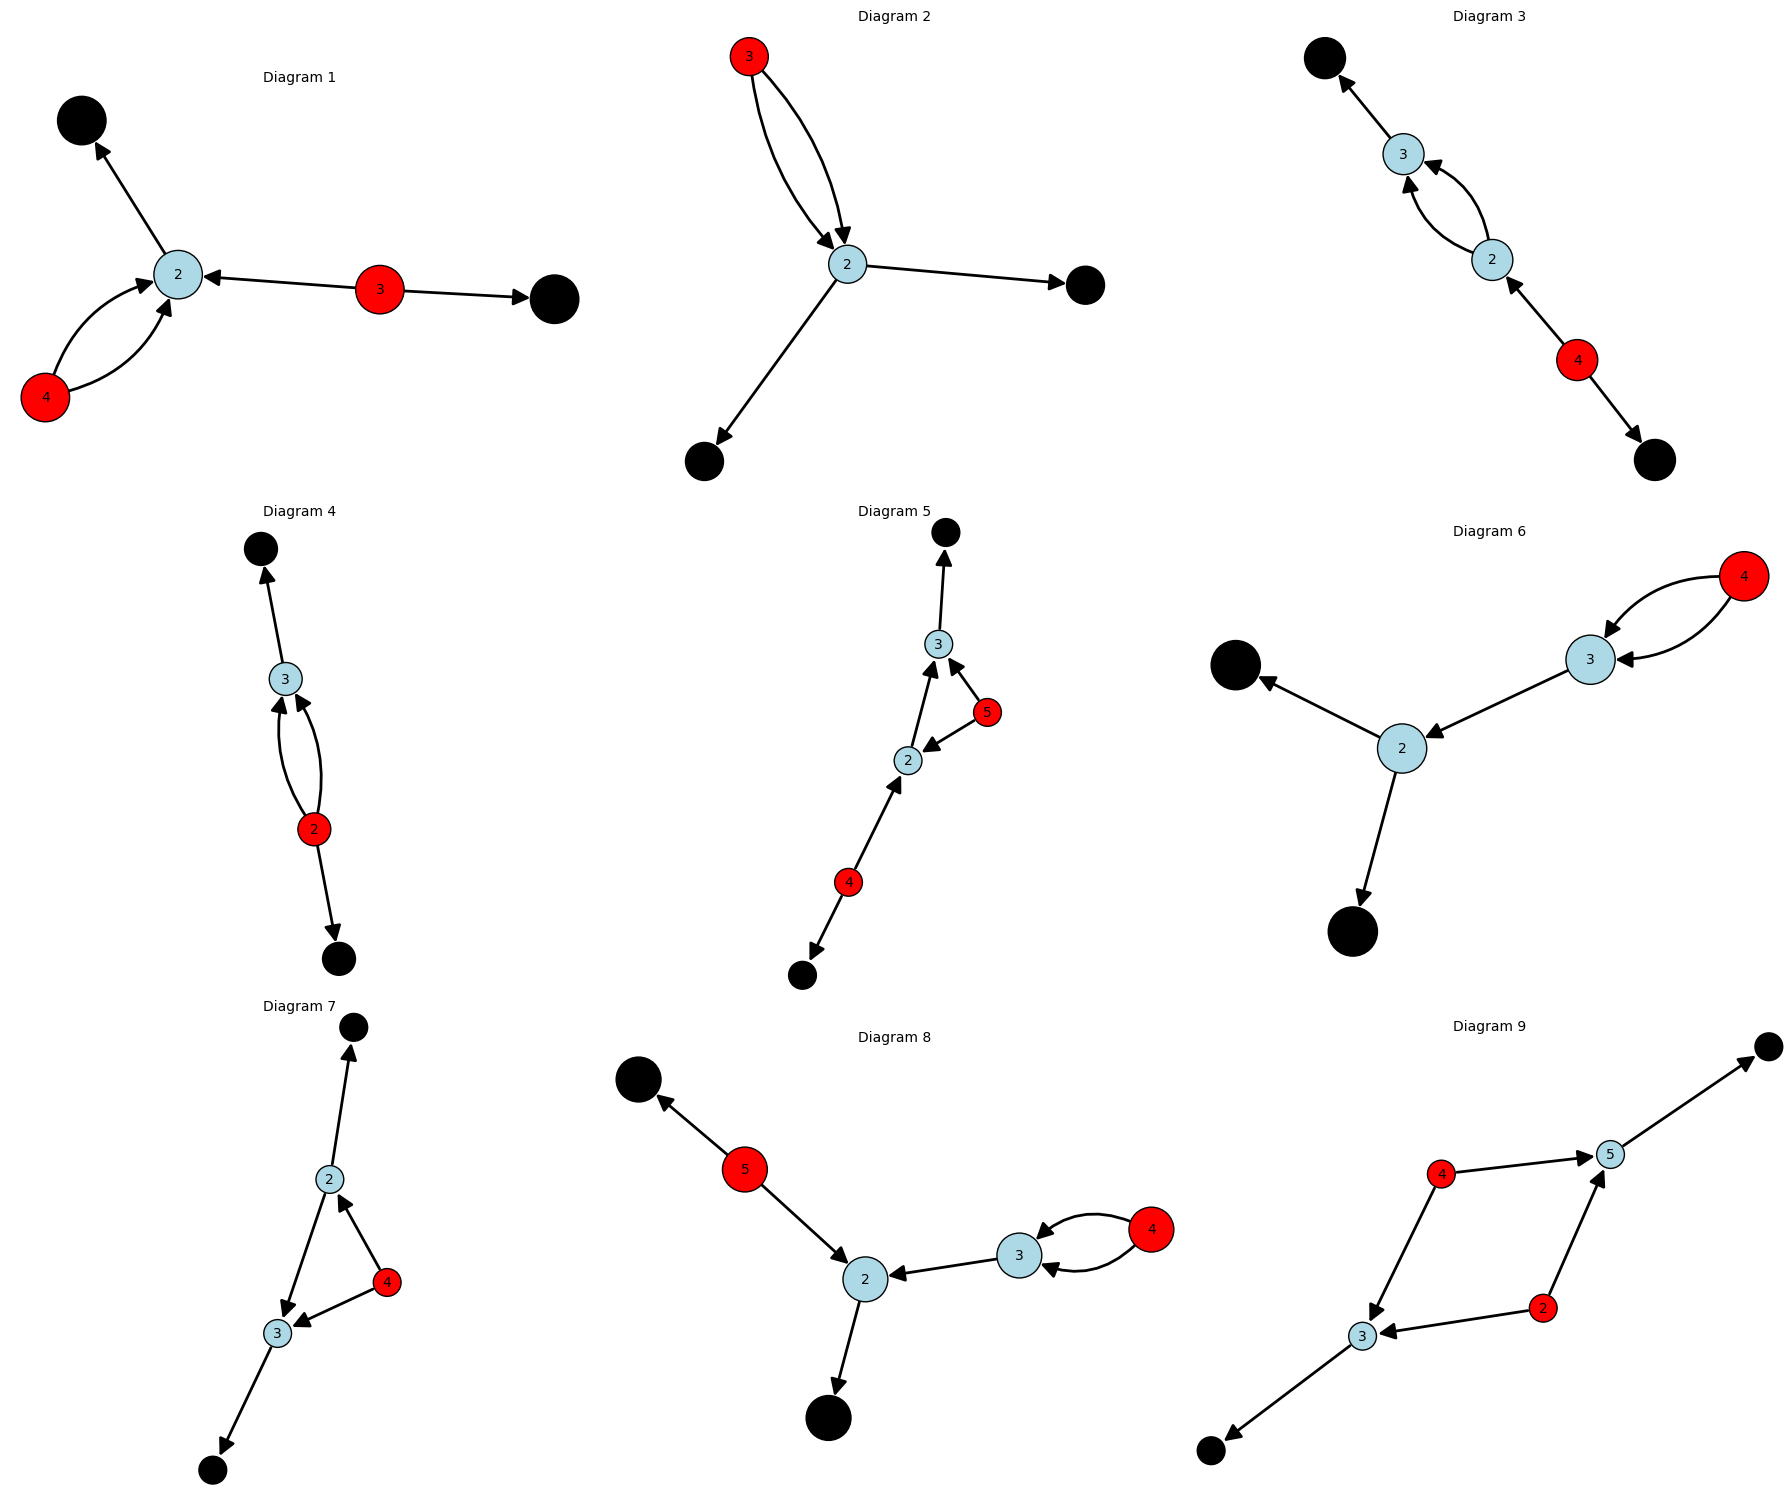


SUMMARY

Diagram 1:
  Leaves (black): [0, 1]
  Sources (red): [3, 4]
  Interactions (blue): []

Diagram 2:
  Leaves (black): [0, 1]
  Sources (red): [3]
  Interactions (blue): []

Diagram 3:
  Leaves (black): [0, 1]
  Sources (red): [4]
  Interactions (blue): [3]

Diagram 4:
  Leaves (black): [0, 1]
  Sources (red): [2]
  Interactions (blue): [3]

Diagram 5:
  Leaves (black): [0, 1]
  Sources (red): [4, 5]
  Interactions (blue): [2, 3]

Diagram 6:
  Leaves (black): [0, 1]
  Sources (red): [4]
  Interactions (blue): [3]

Diagram 7:
  Leaves (black): [0, 1]
  Sources (red): [4]
  Interactions (blue): [3]

Diagram 8:
  Leaves (black): [0, 1]
  Sources (red): [4, 5]
  Interactions (blue): [2, 3]

Diagram 9:
  Leaves (black): [0, 1]
  Sources (red): [2, 4]
  Interactions (blue): [3, 5]


In [14]:
# Cell 10: Visualization of Directed Diagrams

n_graphs = len(unique_directed_diagrams)

if n_graphs == 0:
    print("No diagrams to display!")
else:
    n_cols = min(3, n_graphs)
    n_rows = (n_graphs + n_cols - 1) // n_cols
    
    plots = []
    
    for i, (D, G, leaves, internal) in enumerate(unique_directed_diagrams):
        leaves_set = set(leaves)
        sources = [v for v in D.vertices() if D.in_degree(v) == 0]
        
        color_map = {}
        
        for v in D.vertices():
            if v in leaves_set:
                color_map.setdefault('black', []).append(v)
            elif v in sources:
                color_map.setdefault('red', []).append(v)
            else:
                color_map.setdefault('lightblue', []).append(v)
        
        plot = D.plot(vertex_colors=color_map,
                      vertex_size=400,
                      edge_thickness=2,
                      edge_labels=False,
                      title=f"Diagram {i+1}")
        
        plots.append(plot)
    
    from sage.plot.plot import graphics_array as ga_func
    ga = ga_func(plots, n_rows, n_cols)
    ga.save(f'diagrams_{ell}_loop_{k}_point.png', figsize=[6*n_cols, 5*n_rows], dpi=150)
    ga.show(figsize=[6*n_cols, 5*n_rows])
    
    print(f"\n{'='*60}")
    print("SUMMARY")
    print(f"{'='*60}")
    for i, (D, G, leaves, internal) in enumerate(unique_directed_diagrams):
        sources = [v for v in D.vertices() if D.in_degree(v) == 0]
        interactions = [v for v in D.vertices() if D.in_degree(v) == 2 and D.out_degree(v) == 1]
        
        print(f"\nDiagram {i+1}:")
        print(f"  Leaves (black): {leaves}")
        print(f"  Sources (red): {sources}")
        print(f"  Interactions (blue): {interactions}")

In [15]:
# Cell: Frequency Assignment via Conservation

print("\n" + "="*60)
print("FREQUENCY ASSIGNMENT FOR ALL DIAGRAMS")
print("="*60)

def assign_frequencies_conservation(D, leaves, k):
    """
    Express edge frequencies using conservation.
    Let SageMath determine free parameters, then rename to omega_i.
    """
    from sage.all import var, solve
    
    # Extract all edges
    all_edges = list(D.edges(labels=False))
    n_edges = len(all_edges)
    
    # Create p_i variable for each edge
    edge_vars = [var(f'p_{i}') for i in range(n_edges)]
    
    print(f"\n  Edge variables:")
    for i, (u, v) in enumerate(all_edges):
        print(f"    p_{i} = edge ({u}→{v})")
    
    # Group edges by vertex
    edges_into = {}
    edges_outof = {}
    
    for i, (u, v) in enumerate(all_edges):
        if v not in edges_into:
            edges_into[v] = []
        edges_into[v].append(i)
        
        if u not in edges_outof:
            edges_outof[u] = []
        edges_outof[u].append(i)
    
    # Conservation at vertices with degree >= 2
    all_vertices = set()
    for u, v in all_edges:
        all_vertices.add(u)
        all_vertices.add(v)
    
    equations = []
    print(f"\n  Conservation equations:")
    
    for vertex in sorted(all_vertices):
        in_count = len(edges_into.get(vertex, []))
        out_count = len(edges_outof.get(vertex, []))
        degree = in_count + out_count
        
        if degree < 2:
            continue
        
        in_indices = edges_into.get(vertex, [])
        out_indices = edges_outof.get(vertex, [])
        
        total_in = sum(edge_vars[i] for i in in_indices) if in_indices else 0
        total_out = sum(edge_vars[i] for i in out_indices) if out_indices else 0
        
        eq = total_in == total_out
        equations.append(eq)
        
        in_str = " + ".join([f"p_{i}" for i in in_indices]) if in_indices else "0"
        out_str = " + ".join([f"p_{i}" for i in out_indices]) if out_indices else "0"
        print(f"    v{vertex}: {in_str} = {out_str}")
    
    print(f"\n  System:")
    print(f"    Edge variables: {n_edges}")
    print(f"    Conservation equations: {len(equations)}")
    print(f"    Degrees of freedom: {n_edges - len(equations)}")
    
    # Solve
    print(f"\n  Solving...")
    
    try:
        sol_list = solve(equations, edge_vars, solution_dict=True)
        
        if not sol_list:
            print("  ⚠️ No solution")
            return None
        
        sol = sol_list[0] if isinstance(sol_list, list) else sol_list
        
        print(f"\n  Raw solution from SageMath:")
        for v in edge_vars:
            expr = sol.get(v, v)
            print(f"    {v} = {expr}")
        
        # Find all free parameters introduced by SageMath (r1, r2, etc.)
        free_vars_sage = set()
        for v in edge_vars:
            expr = sol.get(v, v)
            try:
                # Get all variables in the expression
                expr_vars = set(expr.variables())
                # Free parameters are those not in edge_vars
                free_vars_sage.update(expr_vars - set(edge_vars))
            except:
                # If expr is just a variable itself and not in sol, it's free
                if expr == v:
                    free_vars_sage.add(v)
        
        # Sort for consistency
        free_vars_sorted = sorted(free_vars_sage, key=str)
        
        print(f"\n  Free parameters from SageMath: {free_vars_sorted}")
        print(f"  Count: {len(free_vars_sorted)}")
        
        # Rename to omega_0, omega_1, ...
        omega_vars = [var(f'omega_{i}') for i in range(len(free_vars_sorted))]
        renaming = dict(zip(free_vars_sorted, omega_vars))
        
        print(f"\n  Renaming:")
        for old, new in renaming.items():
            print(f"    {old} → {new}")
        
        # Apply renaming to solution
        sol_renamed = {}
        for v in edge_vars:
            expr = sol.get(v, v)
            # Substitute old free vars with omega_i
            expr_renamed = expr
            for old_var, new_var in renaming.items():
                expr_renamed = expr_renamed.subs({old_var: new_var})
            sol_renamed[v] = expr_renamed
        
        print(f"\n  Final solution (with omega variables):")
        for v in edge_vars:
            print(f"    {v} = {sol_renamed[v]}")
        
        # Map to edges
        edge_frequencies = {}
        for i, (u, v) in enumerate(all_edges):
            edge_frequencies[(u, v)] = sol_renamed[edge_vars[i]]
        
        return edge_frequencies, omega_vars
        
    except Exception as e:
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()
        return None, None

# Apply to diagrams
print(f"\nProcessing {len(unique_directed_diagrams)} diagrams...\n")

diagram_frequency_data = []

for num, (D, G, leaves, internal) in enumerate(unique_directed_diagrams):
    print(f"\n{'-'*60}")
    print(f"Diagram {num + 1}:")
    print(f"{'-'*60}")
    
    result = assign_frequencies_conservation(D, leaves, k)
    
    if result and result[0]:
        edge_freq, omega_vars = result
        
        print(f"\n  ✓ Success! Free parameters: {omega_vars}")
        
        diagram_frequency_data.append({
            'diagram': D,
            'topology': G,
            'edge_frequencies': edge_freq,
            'omega_variables': omega_vars,
            'num_free_params': len(omega_vars)
        })

print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"Total diagrams: {len(diagram_frequency_data)}")
if diagram_frequency_data:
    free_param_counts = [d['num_free_params'] for d in diagram_frequency_data]
    print(f"Free parameters per diagram: {free_param_counts}")
    print(f"Expected (k-1+ℓ): {k-1+ell} (may vary due to tadpoles/special topology)")
print(f"{'='*60}")



FREQUENCY ASSIGNMENT FOR ALL DIAGRAMS

Processing 9 diagrams...


------------------------------------------------------------
Diagram 1:
------------------------------------------------------------

  Edge variables:
    p_0 = edge (2→1)
    p_1 = edge (3→0)
    p_2 = edge (3→2)
    p_3 = edge (4→2)
    p_4 = edge (4→2)

  Conservation equations:
    v2: p_2 + p_3 + p_4 = p_0
    v3: 0 = p_1 + p_2
    v4: 0 = p_3 + p_4

  System:
    Edge variables: 5
    Conservation equations: 3
    Degrees of freedom: 2

  Solving...

  Raw solution from SageMath:
    p_0 = r2
    p_1 = -r2
    p_2 = r2
    p_3 = -r1
    p_4 = r1

  Free parameters from SageMath: [r1, r2]
  Count: 2

  Renaming:
    r1 → omega_0
    r2 → omega_1

  Final solution (with omega variables):
    p_0 = omega_1
    p_1 = -omega_1
    p_2 = omega_1
    p_3 = -omega_0
    p_4 = omega_0

  ✓ Success! Free parameters: [omega_0, omega_1]

------------------------------------------------------------
Diagram 2:
----------------

In [16]:
# Cell: Time Assignment for Vertices and Edges

print(f"\n{'='*60}")
print(f"TIME ASSIGNMENT FOR ALL DIAGRAMS")
print(f"{'='*60}\n")

def assign_times_to_diagram(D, leaves):
    """
    Assign times to vertices and edges.
    
    - External vertices (leaves): t_1, t_2, ..., t_k
    - Internal vertices: tau_1, tau_2, ...
    - Source vertices: Multiple times, one per outgoing edge
    - Edges: Pairs of times (t_from, t_to)
    """
    from sage.all import var
    
    # Get all edges
    all_edges = list(D.edges(labels=False))
    
    # Identify vertex types
    sources = [v for v in D.vertices() if D.in_degree(v) == 0]
    leaves_set = set(leaves)
    internal_vertices = [v for v in D.vertices() if v not in leaves_set and v not in sources]
    
    # Vertex time assignments
    vertex_times = {}
    
    # 1. External vertices get t_i
    for i, leaf in enumerate(leaves):
        t_i = var(f't_{i}')
        vertex_times[leaf] = t_i
    
    # 2. Internal vertices get tau_i
    for i, v in enumerate(internal_vertices):
        tau_i = var(f'tau_{i}')
        vertex_times[v] = tau_i
    
    # 3. Source vertices get multiple times (one per outgoing edge)
    source_edge_times = {}  # Maps (source, edge_index) -> time variable
    
    for src in sources:
        outgoing = [e for e in all_edges if e[0] == src]
        out_degree = len(outgoing)
        
        # Assign times to this source's outgoing edges
        for i, edge in enumerate(outgoing):
            s_time = var(f's_{src}_{i}')
            source_edge_times[(src, edge)] = s_time
    
    # Edge time assignments
    edge_times = {}
    
    for edge in all_edges:
        u, v = edge
        
        # Determine t_from
        if u in sources:
            # Source vertex - use the unique time for this edge
            t_from = source_edge_times[(u, edge)]
        else:
            # Regular vertex - use its single time
            t_from = vertex_times[u]
        
        # Determine t_to
        t_to = vertex_times[v]
        
        edge_times[edge] = (t_from, t_to)
    
    return vertex_times, source_edge_times, edge_times

# Apply to all diagrams
print(f"Assigning times to {len(diagram_frequency_data)} diagrams...\n")

for i, data in enumerate(diagram_frequency_data):
    print(f"\n{'-'*60}")
    print(f"Diagram {i+1}:")
    print(f"{'-'*60}")
    
    D = data['diagram']
    leaves = [v for v in D.vertices() if D.out_degree(v) == 0]
    sources = [v for v in D.vertices() if D.in_degree(v) == 0]
    
    vertex_times, source_edge_times, edge_times = assign_times_to_diagram(D, leaves)
    
    print(f"\n  Vertex times:")
    for v in sorted(vertex_times.keys()):
        vtype = 'ext' if v in leaves else 'int'
        print(f"    v{v} [{vtype}]: {vertex_times[v]}")
    
    print(f"\n  Source edge times:")
    if source_edge_times:
        for (src, edge), s_time in sorted(source_edge_times.items()):
            print(f"    Source v{src}, edge {edge}: {s_time}")
    else:
        print(f"    (No sources)")
    
    print(f"\n  Edge times (t_from, t_to):")
    for edge, (t_from, t_to) in sorted(edge_times.items()):
        u, v = edge
        print(f"    ({u}→{v}): ({t_from}, {t_to})")
    
    # Store in data
    data['vertex_times'] = vertex_times
    data['source_edge_times'] = source_edge_times
    data['edge_times'] = edge_times

print(f"\n{'='*60}")
print(f"TIME ASSIGNMENT COMPLETE")
print(f"{'='*60}")



TIME ASSIGNMENT FOR ALL DIAGRAMS

Assigning times to 9 diagrams...


------------------------------------------------------------
Diagram 1:
------------------------------------------------------------

  Vertex times:
    v0 [ext]: t_0
    v1 [ext]: t_1
    v2 [int]: tau_0

  Source edge times:
    Source v3, edge (3, 0): s_3_0
    Source v3, edge (3, 2): s_3_1
    Source v4, edge (4, 2): s_4_1

  Edge times (t_from, t_to):
    (2→1): (tau_0, t_1)
    (3→0): (s_3_0, t_0)
    (3→2): (s_3_1, tau_0)
    (4→2): (s_4_1, tau_0)

------------------------------------------------------------
Diagram 2:
------------------------------------------------------------

  Vertex times:
    v0 [ext]: t_0
    v1 [ext]: t_1
    v2 [int]: tau_0

  Source edge times:
    Source v3, edge (3, 2): s_3_1

  Edge times (t_from, t_to):
    (2→0): (tau_0, t_0)
    (2→1): (tau_0, t_1)
    (3→2): (s_3_1, tau_0)

------------------------------------------------------------
Diagram 3:
------------------------------

In [17]:
# Cell: Plot Diagrams with Frequency Labels

print(f"\n{'='*60}")
print(f"PLOTTING DIAGRAMS WITH FREQUENCY LABELS")
print(f"{'='*60}\n")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_diagram_with_frequencies(D, edge_frequencies, omega_vars, diagram_num, leaves):
    """
    Plot directed graph with edge frequency labels.
    """
    # Identify vertex types
    sources = [v for v in D.vertices() if D.in_degree(v) == 0]
    leaves_set = set(leaves)
    
    # Create color map
    color_map = {}
    for v in D.vertices():
        if v in leaves_set:
            color_map.setdefault('black', []).append(v)
        elif v in sources:
            color_map.setdefault('red', []).append(v)
        else:
            color_map.setdefault('lightblue', []).append(v)
    
    # Get positions FIRST
    pos = D.layout_spring()
    
    # Create plot WITH EXPLICIT positions
    plot = D.plot(
        pos=pos,
        vertex_colors=color_map,
        vertex_size=800,
        figsize=10
    )
    
    # Get matplotlib figure
    fig = plot.matplotlib()
    ax = fig.axes[0]
    
    # Now manually add edge labels using the SAME pos
    all_edges = list(D.edges(labels=False))
    
    from collections import defaultdict
    edge_groups = defaultdict(list)
    for edge in all_edges:
        u, v = edge
        freq = edge_frequencies.get(edge, '?')
        edge_groups[(u, v)].append(str(freq))
    
    for (u, v), freqs in edge_groups.items():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        
        if len(freqs) == 1:
            # Single edge
            mid_x = (x1 + x2) / 2
            mid_y = (y1 + y2) / 2
            ax.text(mid_x, mid_y, f'${freqs[0]}$',
                   fontsize=10, ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', 
                            edgecolor='black', alpha=0.9),
                   zorder=10)
        else:
            # Multiple parallel edges
            dx = x2 - x1
            dy = y2 - y1
            length = (dx**2 + dy**2)**0.5
            if length > 0:
                perp_x = -dy / length * 0.2
                perp_y = dx / length * 0.2
                
                for i, freq in enumerate(freqs):
                    offset = (i - (len(freqs) - 1) / 2)
                    mid_x = (x1 + x2) / 2 + offset * perp_x
                    mid_y = (y1 + y2) / 2 + offset * perp_y
                    
                    ax.text(mid_x, mid_y, f'${freq}$',
                           fontsize=9, ha='center', va='center',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow',
                                    edgecolor='black', alpha=0.9),
                           zorder=10)
    
    # Title
    omega_str = ', '.join([str(om) for om in omega_vars])
    ax.set_title(f'Diagram {diagram_num}\nFree parameters: {omega_str}',
                fontsize=12, fontweight='bold', pad=20)
    
    # Legend
    legend_elements = [
        mpatches.Patch(facecolor='black', edgecolor='black', label='External'),
        mpatches.Patch(facecolor='red', edgecolor='black', label='Source'),
        mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Internal')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    # Save
    filename = f'diagram_{diagram_num}_frequencies.png'
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    
    return filename

# Plot all diagrams
print(f"Plotting {len(diagram_frequency_data)} diagrams...\n")

plot_files = []

for i, data in enumerate(diagram_frequency_data):
    D = data['diagram']
    edge_freq = data['edge_frequencies']
    omega_vars = data['omega_variables']
    
    leaves = [v for v in D.vertices() if D.out_degree(v) == 0]
    
    print(f"Diagram {i+1}: ", end='')
    try:
        filename = plot_diagram_with_frequencies(D, edge_freq, omega_vars, i+1, leaves)
        plot_files.append(filename)
        omega_str = ', '.join([str(om) for om in omega_vars])
        print(f"✓ {filename} (params: {omega_str})")
    except Exception as e:
        print(f"⚠️ Error: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*60}")
print(f"Saved {len(plot_files)} plots")
print(f"{'='*60}")



PLOTTING DIAGRAMS WITH FREQUENCY LABELS

Plotting 9 diagrams...

Diagram 1: ✓ diagram_1_frequencies.png (params: omega_0, omega_1)
Diagram 2: ✓ diagram_2_frequencies.png (params: omega_0, omega_1)
Diagram 3: ✓ diagram_3_frequencies.png (params: omega_0, omega_1)
Diagram 4: ✓ diagram_4_frequencies.png (params: omega_0, omega_1)
Diagram 5: ✓ diagram_5_frequencies.png (params: omega_0, omega_1)
Diagram 6: ✓ diagram_6_frequencies.png (params: omega_0, omega_1)
Diagram 7: ✓ diagram_7_frequencies.png (params: omega_0, omega_1)
Diagram 8: ✓ diagram_8_frequencies.png (params: omega_0, omega_1)
Diagram 9: ✓ diagram_9_frequencies.png (params: omega_0, omega_1)

Saved 9 plots


In [18]:
# Cell: Save Diagram Data to NPZ Files

print(f"\n{'='*60}")
print(f"SAVING DIAGRAM DATA TO NPZ FILES")
print(f"{'='*60}\n")

import numpy as np
import os

# Create directory for this (k, ell) pair
output_dir = f'diagrams_k{k}_ell{ell}'
os.makedirs(output_dir, exist_ok=True)
print(f"Saving to directory: {output_dir}/\n")

for i, data in enumerate(diagram_frequency_data):
    D = data['diagram']
    
    # Extract graph structure
    vertices = list(D.vertices())
    edges = list(D.edges(labels=False))
    
    # Vertex types
    leaves = [v for v in vertices if D.out_degree(v) == 0]
    sources = [v for v in vertices if D.in_degree(v) == 0]
    internal = [v for v in vertices if v not in leaves and v not in sources]
    
    vertex_types = {}
    for v in vertices:
        if v in leaves:
            vertex_types[v] = 'external'
        elif v in sources:
            vertex_types[v] = 'source'
        else:
            vertex_types[v] = 'internal'
    
    # Edge list as array
    edge_array = np.array(edges, dtype=int)
    
    # Vertex data
    vertex_list = np.array(vertices, dtype=int)
    vertex_type_array = np.array([vertex_types[v] for v in vertices], dtype=str)
    
    # Frequencies (convert to strings for storage)
    edge_freq = data['edge_frequencies']
    edge_freq_str = np.array([str(edge_freq[e]) for e in edges], dtype=str)
    omega_vars_str = np.array([str(om) for om in data['omega_variables']], dtype=str)
    
    # Times (convert to strings for storage)
    vertex_times = data['vertex_times']
    vertex_times_str = np.array([str(vertex_times.get(v, 'N/A')) for v in vertices], dtype=str)
    
    edge_times = data['edge_times']
    edge_times_from_str = np.array([str(edge_times[e][0]) for e in edges], dtype=str)
    edge_times_to_str = np.array([str(edge_times[e][1]) for e in edges], dtype=str)
    
    # Source edge times (if any)
    source_edge_times = data['source_edge_times']
    if source_edge_times:
        source_info = []
        for (src, edge), s_time in source_edge_times.items():
            source_info.append(f"src={src},edge={edge},time={s_time}")
        source_edge_times_str = np.array(source_info, dtype=str)
    else:
        source_edge_times_str = np.array([], dtype=str)
    
    # Symmetry factor
    symmetry_factor = data['topology'].automorphism_group().order()
    
    # Save to npz with k and ell in filename
    filename = f'diagram_k{k}_ell{ell}_num{i+1}.npz'
    filepath = os.path.join(output_dir, filename)
    
    np.savez(
        filepath,
        # Graph structure
        vertices=vertex_list,
        edges=edge_array,
        vertex_types=vertex_type_array,
        # Frequencies
        edge_frequencies=edge_freq_str,
        omega_variables=omega_vars_str,
        num_free_params=len(data['omega_variables']),
        # Times
        vertex_times=vertex_times_str,
        edge_times_from=edge_times_from_str,
        edge_times_to=edge_times_to_str,
        source_edge_times=source_edge_times_str,
        # Metadata
        symmetry_factor=symmetry_factor,
        k=k,
        ell=ell
    )
    
    print(f"Diagram {i+1}: {filename}")
    print(f"  Vertices: {len(vertices)}, Edges: {len(edges)}")
    print(f"  Free params: {len(data['omega_variables'])}, Symmetry: {symmetry_factor}")

print(f"\n{'='*60}")
print(f"SAVED {len(diagram_frequency_data)} DIAGRAMS to {output_dir}/")
print(f"{'='*60}")

# Show how to load
print(f"\nTo load a diagram:")
print(f"  data = np.load('{output_dir}/diagram_k{k}_ell{ell}_num1.npz', allow_pickle=True)")
print(f"  edges = data['edges']")
print(f"  edge_frequencies = data['edge_frequencies']")



SAVING DIAGRAM DATA TO NPZ FILES

Saving to directory: diagrams_k2_ell1/

Diagram 1: diagram_k2_ell1_num1.npz
  Vertices: 5, Edges: 5
  Free params: 2, Symmetry: 1
Diagram 2: diagram_k2_ell1_num2.npz
  Vertices: 4, Edges: 4
  Free params: 2, Symmetry: 2
Diagram 3: diagram_k2_ell1_num3.npz
  Vertices: 5, Edges: 5
  Free params: 2, Symmetry: 1
Diagram 4: diagram_k2_ell1_num4.npz
  Vertices: 4, Edges: 4
  Free params: 2, Symmetry: 2
Diagram 5: diagram_k2_ell1_num5.npz
  Vertices: 6, Edges: 6
  Free params: 2, Symmetry: 1
Diagram 6: diagram_k2_ell1_num6.npz
  Vertices: 5, Edges: 5
  Free params: 2, Symmetry: 2
Diagram 7: diagram_k2_ell1_num7.npz
  Vertices: 5, Edges: 5
  Free params: 2, Symmetry: 2
Diagram 8: diagram_k2_ell1_num8.npz
  Vertices: 6, Edges: 6
  Free params: 2, Symmetry: 1
Diagram 9: diagram_k2_ell1_num9.npz
  Vertices: 6, Edges: 6
  Free params: 2, Symmetry: 4

SAVED 9 DIAGRAMS to diagrams_k2_ell1/

To load a diagram:
  data = np.load('diagrams_k2_ell1/diagram_k2_ell1_num1.